In [83]:
import pandas as pd
import numpy as np
import os

In [84]:
from typing import List, Optional
from Bio import Phylo

def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)
    
def tip_order_from_nexus_biopython(
    nexus_path: str,
    tree_label: Optional[str] = None
) -> List[str]:
    """
    Returns the left-to-right tip (sample) order from a NEXUS file using Biopython.
    If `tree_label` is given, picks that named tree; else the first tree in the file.
    """
    trees = list(Phylo.parse(nexus_path, "nexus"))
    if not trees:
        raise ValueError("No trees found in NEXUS file.")

    if tree_label is not None:
        matches = [t for t in trees if (t.name or "") == tree_label]
        if not matches:
            raise ValueError(f"Tree labeled '{tree_label}' not found.")
        tree = matches[0]
    else:
        tree = trees[0]

    tip_order = [clade.name for clade in tree.find_clades(order="preorder") if clade.is_terminal()]
    return tip_order

In [85]:
phylogeneticOrder=()
tips_bio = tip_order_from_nexus_biopython("/LeeLab/HPRC/chromosomeY/Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex")         # first tree

for sample in tips_bio:
    phylogeneticOrder = add_feature(phylogeneticOrder, sample)
   
print(phylogeneticOrder)
print(len(phylogeneticOrder))

haplogroups={}
phylDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/HPRC_HGSVC3_sample_annotations_20March2025.txt",sep='\t')#
phylDF['GoodSampleNames']=[x.split("/")[1] if '/' in x else x for x in phylDF['sample']]
phylDF.set_index("GoodSampleNames", inplace=True)

for sample in phylogeneticOrder:
    if sample in phylDF.index:
        haplogroups[sample]=phylDF.at[sample,'haplogroup_ISOGG_v15.73']
    else:
        continue

haplogroups['NA12877']='R1b1a1b1a1a2e2'
haplogroups['NA12882']='R1b1a1b1a1a2e2'
haplogroups['NA12886']='R1b1a1b1a1a2e2'
haplogroups['200080']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200084']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200085']='R1b1a1b1a1a1c2b2b1a'

print(len(haplogroups))

('HG02984', 'HG01890', 'HG02647', 'HG02666', 'HG02668', 'HG03225', 'NA19043', 'NA19384', 'HG005', 'NA18952', 'NA18983', 'HG02572', 'HG03248', 'HG03098', 'HG03050', 'NA19239', 'HG01074', 'HG01109', 'HG01106', 'NA19331', 'HG01252', 'HG01457', 'HG03065', 'HG02717', 'HG03471', 'HG02011', 'HG03371', 'HG02486', 'HG02965', 'HG03139', 'NA19443', 'NA19317', 'NA19347', 'NA20346', 'HG02145', 'HG02258', 'HG02953', 'HG03130', 'HG03521', 'HG02554', 'NA18879', 'HG03209', 'NA18522', 'NA19700', 'HG02055', 'NA19705', 'NA18612', 'NA18620', 'HG04157', 'NA18989', 'NA18971', 'NA18974', 'HG02040', 'NA20870', 'HG03710', 'HG01099', 'HG03579', 'NA21093', 'HG04187', 'HG03009', 'HG03942', 'HG01167', 'HG00140', 'HG00321', 'NA20905', 'HG02492', 'HG02735', 'NA20805', 'NA20809', 'HG01255', 'HG01258', 'HG01433', 'HG003', 'HG002', 'HG03688', 'HG04199', 'HG01192', 'HG01530', 'HG03742', 'NA18608', 'NA18747', 'HG00280', 'HG00329', 'HG00290', 'HG00358', 'HG02015', 'HG02083', 'HG02514', 'HG02074', 'NA18534', 'HG02027', 'HG0

In [86]:
goodTSPYSamples=[]
with open('/LeeLab/HPRC/chromosomeY/QC/LocationFiles/TSPY_QC_File.txt','r') as inFile:
    for line in inFile:
        goodTSPYSamples.append(line.strip())

print(len(goodTSPYSamples))

110


In [7]:
goodRBMYSamples=[]
with open('/LeeLab/HPRC/chromosomeY/QC/LocationFiles/RBMY_QC_File.txt','r') as inFile:
    for line in inFile:
        goodRBMYSamples.append(line.strip())
print(len(goodRBMYSamples))

126


In [47]:
ampliconicDataframe=pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/HGSVC3_HPRC_CEPH-AmpliconicGenes_combined_wLiftOff_plusManualAnnotation_nodbGaPSamples.09132025.csv')
ampliconicDataframe2 = ampliconicDataframe[(ampliconicDataframe['geneCompletenessInfo']=='Full_Exon_Copy') &(ampliconicDataframe['sampleName'].isin(goodRBMYSamples)) & (ampliconicDataframe['geneName']=='RBMY1B')][['sampleName','contig','geneCompletenessInfo','contigStart','contigEnd','orientation']].copy()

In [90]:
tspyDF = ampliconicDataframe[(ampliconicDataframe['geneCompletenessInfo']=='Full_Exon_Copy') &(ampliconicDataframe['sampleName'].isin(goodTSPYSamples)) & (ampliconicDataframe['geneName']=='TSPY1')][['sampleName','contig','geneCompletenessInfo','contigStart','contigEnd','orientation']].copy()
tspyDF['Haplogroup'] = [haplogroups[x][:1] for x in tspyDF['sampleName']]

In [91]:
tspyDF

,sampleName,contig,geneCompletenessInfo,contigStart,contigEnd,orientation,Haplogroup
0,HG00126,HG00126_chrY,Full_Exon_Copy,5906637,5909427,+,R
2,HG00126,HG00126_chrY,Full_Exon_Copy,8948612,8951408,+,R
3,HG00126,HG00126_chrY,Full_Exon_Copy,8968924,8971720,+,R
4,HG00126,HG00126_chrY,Full_Exon_Copy,8989248,8992062,+,R
5,HG00126,HG00126_chrY,Full_Exon_Copy,9009540,9012336,+,R
...,...,...,...,...,...,...,...
9183,NA12882,NA12882_chrY,Full_Exon_Copy,9414444,9417240,+,R
9184,NA12882,NA12882_chrY,Full_Exon_Copy,9434753,9437567,+,R
9185,NA12882,NA12882_chrY,Full_Exon_Copy,9455050,9457864,+,R
9186,NA12882,NA12882_chrY,Full_Exon_Copy,9475323,9478137,+,R


In [48]:
flipped = ['HG02666','NA20905','HG02602']

In [49]:
import pandas as pd

df = ampliconicDataframe2.sort_values(['sampleName', 'contigStart']).copy()
df['prev_end'] = df.groupby('sampleName')['contigEnd'].shift(1)
df['new_group'] = (
    (df['contigStart'] - df['prev_end'] > 100000) |
    (df['prev_end'].isna())
)

df['group_id'] = df.groupby('sampleName')['new_group'].cumsum()

In [50]:
group_sizes = (
    df.groupby(['sampleName', 'group_id'])
      .size()
      .reset_index(name='n_genes')
)

In [51]:
n_groups_per_sample = (
    group_sizes.groupby('sampleName')['group_id']
    .nunique()
    .reset_index(name='n_groups')
)

In [52]:
import pandas as pd

flipped = ['HG02666', 'NA20905', 'HG02602']

# remove singleton groups
normal_groups  = [3, 4, 5, 6]
flipped_groups = [1, 2]

mask_remove = (
    (
        (~group_sizes['sampleName'].isin(flipped)) &
        (group_sizes['group_id'].isin(normal_groups))
    )
    |
    (
        (group_sizes['sampleName'].isin(flipped)) &
        (group_sizes['group_id'].isin(flipped_groups))
    )
) & (group_sizes['n_genes'] == 1)

group_sizes_filtered = group_sizes.loc[~mask_remove].copy()
removed_groups = group_sizes.loc[mask_remove].copy()

In [53]:
flip_map = {1: 4, 2: 3, 3: 2, 4: 1, 5: 6, 6: 5}

group_sizes_filtered['group_id_norm'] = group_sizes_filtered['group_id']

mask_flipped = group_sizes_filtered['sampleName'].isin(flipped)
group_sizes_filtered.loc[mask_flipped, 'group_id_norm'] = (
    group_sizes_filtered.loc[mask_flipped, 'group_id'].map(flip_map)
)
def get_mode(x):
    m = x.mode()
    if len(m) == 0:
        return pd.NA
    elif len(m) == 1:
        return m.iloc[0]
    else:
        return list(m)

summary = (
    group_sizes_filtered.groupby('group_id_norm')['n_genes']
    .agg(
        mean='mean',
        median='median',
        min='min',
        max='max',
        std='std',
        n_samples='size'
    )
    .reset_index()
)

mode_df = (
    group_sizes_filtered.groupby('group_id_norm')['n_genes']
    .apply(get_mode)
    .reset_index(name='mode')
)

summary = summary.merge(mode_df, on='group_id_norm').sort_values('group_id_norm')

In [60]:
group_sizes_filtered['Haplogroup'] = [haplogroups[x][:1] for x in group_sizes_filtered['sampleName']]

In [62]:
haplogroup_colors = {
    'A':  '#B2182B',
    'B':  '#D6604D',
    'E':  '#F4A582',
    'D':  '#2166AC',
    'C':  '#1F78B4',
    'F':  '#2C7FB8',
    'G':  '#41B6C4',
    'H':  '#1D91C0',
    'I':  '#6A3D9A',
    'J':  '#0C7C59',
    'L':  '#28A745',
    'T':  '#C77C2E',
    'NO': '#4D9221',
    'N':  '#7FBC41',
    'O':  '#008B8B',
    'Q':  '#A6761D',
    'R':  '#8E63B0',
}

/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_6722/246982442.py:28: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_6722/246982442.py:42: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


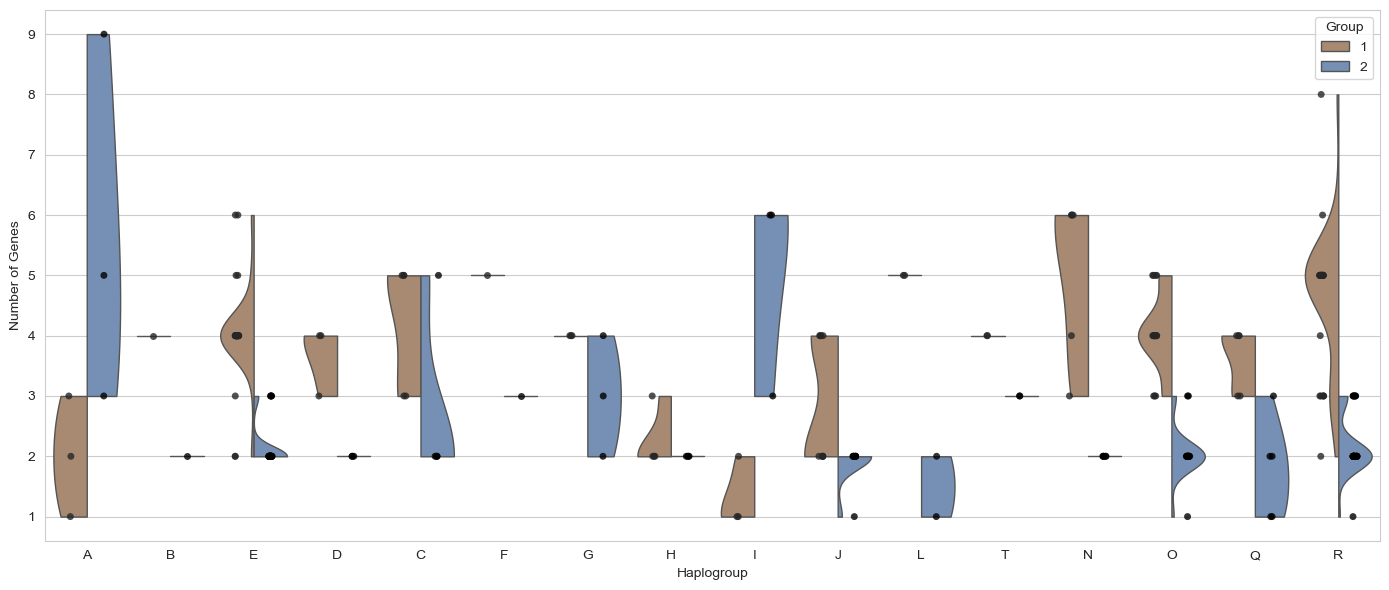

In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = group_sizes_filtered.copy()
df_plot = df_plot[df_plot['group_id_norm'].isin([1, 2])].copy()

hap_order = [h for h in haplogroup_colors.keys() if h in df_plot['Haplogroup'].dropna().unique()]
df_plot['Haplogroup'] = pd.Categorical(
    df_plot['Haplogroup'],
    categories=hap_order,
    ordered=True
)

group_order = [1, 2]

group_palette = {
    1: "#B08968", 
    2: "#6C8EBF",  
}

sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

ax = sns.violinplot(
    data=df_plot,
    x='Haplogroup',
    y='n_genes',
    hue='group_id_norm',
    order=hap_order,
    hue_order=group_order,
    palette=group_palette,
    split=True,
    inner=None,   
    cut=0,
    scale='width',
    linewidth=1
)
sns.stripplot(
    data=df_plot,
    x='Haplogroup',
    y='n_genes',
    hue='group_id_norm',
    order=hap_order,
    hue_order=group_order,
    dodge=True,
    jitter=0.05,
    size=5,
    alpha=0.8,
    color='black',
    ax=ax
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[:len(group_order)],
    labels[:len(group_order)],
    title="Group",
    loc='upper right'
)

ax.set_xlabel("Haplogroup")
ax.set_ylabel("Number of Genes")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [97]:
newList=[]
for sample in set(tspyDF['sampleName']):
    tspyDF2 = tspyDF[tspyDF['sampleName']==sample].copy()
    newList.append([sample, len(tspyDF2), haplogroups[sample][:1]])
tspyCount = pd.DataFrame(data=newList, columns=['sample','count','haplogroup'])

/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_6722/3563644001.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_6722/3563644001.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_6722/3563644001.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


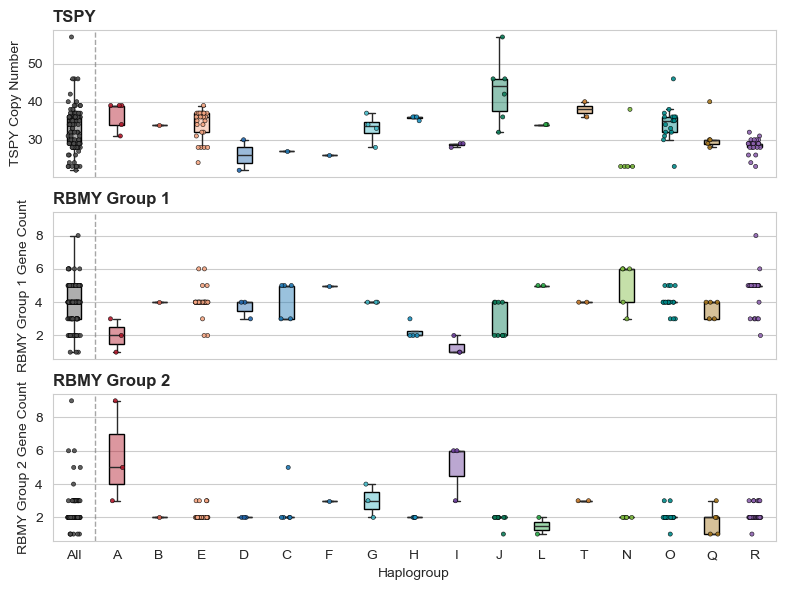

In [117]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba


haplogroup_colors = {
    'A':  '#B2182B',
    'B':  '#D6604D',
    'E':  '#F4A582',
    'D':  '#2166AC',
    'C':  '#1F78B4',
    'F':  '#2C7FB8',
    'G':  '#41B6C4',
    'H':  '#1D91C0',
    'I':  '#6A3D9A',
    'J':  '#0C7C59',
    'L':  '#28A745',
    'T':  '#C77C2E',
    'NO': '#4D9221',
    'N':  '#7FBC41',
    'O':  '#008B8B',
    'Q':  '#A6761D',
    'R':  '#8E63B0',
}

sns.set_style("whitegrid")


present_haps = (
    set(tspyCount['haplogroup'].dropna().unique())
    | set(group_sizes_filtered['Haplogroup'].dropna().unique())
)
hap_order = ['All'] + [h for h in haplogroup_colors.keys() if h in present_haps]


hap_palette = {'All': '#4D4D4D'}
hap_palette.update(haplogroup_colors)


tspy_plot = tspyCount.copy().rename(
    columns={'haplogroup': 'Haplogroup', 'count': 'value'}
)

tspy_all = tspy_plot.copy()
tspy_all['Haplogroup'] = 'All'

tspy_plot = pd.concat([tspy_all, tspy_plot], ignore_index=True)
tspy_plot['Haplogroup'] = pd.Categorical(
    tspy_plot['Haplogroup'],
    categories=hap_order,
    ordered=True
)


rbmy = group_sizes_filtered.copy()
rbmy = rbmy[rbmy['group_id_norm'].isin([1, 2])].copy()
rbmy = rbmy.rename(columns={'n_genes': 'value'})

rbmy_g1 = rbmy[rbmy['group_id_norm'] == 1].copy()
rbmy_g1_all = rbmy_g1.copy()
rbmy_g1_all['Haplogroup'] = 'All'
rbmy_g1_plot = pd.concat([rbmy_g1_all, rbmy_g1], ignore_index=True)
rbmy_g1_plot['Haplogroup'] = pd.Categorical(
    rbmy_g1_plot['Haplogroup'],
    categories=hap_order,
    ordered=True
)


rbmy_g2 = rbmy[rbmy['group_id_norm'] == 2].copy()
rbmy_g2_all = rbmy_g2.copy()
rbmy_g2_all['Haplogroup'] = 'All'
rbmy_g2_plot = pd.concat([rbmy_g2_all, rbmy_g2], ignore_index=True)
rbmy_g2_plot['Haplogroup'] = pd.Categorical(
    rbmy_g2_plot['Haplogroup'],
    categories=hap_order,
    ordered=True
)

rbmy_combined = pd.concat([rbmy_g1_plot, rbmy_g2_plot], ignore_index=True)
rbmy_ymin = rbmy_combined['value'].min()
rbmy_ymax = rbmy_combined['value'].max()

if rbmy_ymax == rbmy_ymin:
    pad = 0.5
else:
    pad = (rbmy_ymax - rbmy_ymin) * 0.05

rbmy_ymin -= pad
rbmy_ymax += pad

fig, axes = plt.subplots(
    3, 1,
    figsize=(8, 6),
    sharex=True
)

panel_data = [
    (axes[0], tspy_plot, "TSPY Copy Number"),
    (axes[1], rbmy_g1_plot, "RBMY Group 1 Gene Count"),
    (axes[2], rbmy_g2_plot, "RBMY Group 2 Gene Count"),
]

for i, (ax, dfp, ylabel) in enumerate(panel_data):
    # boxplot
    sns.boxplot(
        data=dfp,
        x='Haplogroup',
        y='value',
        order=hap_order,
        palette=hap_palette,
        width=0.35,
        fliersize=0,
        linewidth=1,
        ax=ax
    )


    for patch, hap in zip(ax.patches[:len(hap_order)], hap_order):
        patch.set_facecolor(to_rgba(hap_palette[hap], alpha=0.45))
        patch.set_edgecolor('black')
        patch.set_linewidth(1)

    sns.stripplot(
        data=dfp,
        x='Haplogroup',
        y='value',
        order=hap_order,
        hue='Haplogroup',
        palette=hap_palette,
        dodge=False,
        jitter=0.15,
        size=3,
        alpha=0.9,
        edgecolor='black',
        linewidth=0.4,
        ax=ax
    )


    if ax.get_legend() is not None:
        ax.get_legend().remove()


    ax.axvline(
        x=0.5,
        color='gray',
        linestyle='--',
        linewidth=1,
        alpha=0.7
    )


    if i in [1, 2]:
        ax.set_ylim(rbmy_ymin, rbmy_ymax)

    ax.set_ylabel(ylabel)
    ax.set_xlabel("")

# Titles
axes[0].set_title("TSPY", loc='left', fontweight='bold')
axes[1].set_title("RBMY Group 1", loc='left', fontweight='bold')
axes[2].set_title("RBMY Group 2", loc='left', fontweight='bold')


axes[2].set_xlabel("Haplogroup")

plt.xticks(rotation=0)
plt.tight_layout()

#fig.savefig("/tspy_rbmy_3panel.pdf", bbox_inches='tight')
#fig.savefig("/tspy_rbmy_3panel.png", dpi=300, bbox_inches='tight')

plt.show()